##                     Diabetes Risk Prediction

# **1. Importing Dataset**

In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/datasets/alexteboul/diabetes-health-indicators-dataset'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/alexteboul/diabetes-health-indicators-dataset/diabetes_binary_5050split_health_indicators_BRFSS2015.csv
/kaggle/input/datasets/alexteboul/diabetes-health-indicators-dataset/diabetes_binary_health_indicators_BRFSS2015.csv
/kaggle/input/datasets/alexteboul/diabetes-health-indicators-dataset/diabetes_012_health_indicators_BRFSS2015.csv


In [9]:
file_path = '/kaggle/input/datasets/alexteboul/diabetes-health-indicators-dataset/diabetes_012_health_indicators_BRFSS2015.csv'

dataframe = pd.read_csv(file_path)

# **2. Describing Dataset**

In [10]:
dataframe.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [11]:
dataframe.isnull().sum()

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

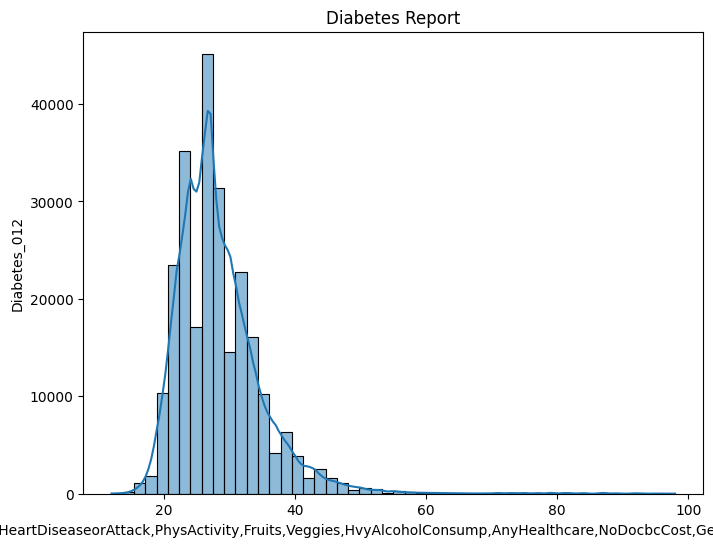

In [13]:
plt.figure(figsize=(8,6))
sns.histplot(dataframe['BMI'],bins=50,kde=True)
plt.title('Diabetes Report')
plt.xlabel("Age,HighBP,HighChol,CholCHeck,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Education,Income")
plt.ylabel("Diabetes_012")
plt.show()

In [14]:
dataframe.isnull().sum()

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [15]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

# **3. Data Preprocessing**

In [16]:
float_columns = dataframe.select_dtypes(include=['float']).columns
dataframe[float_columns] = dataframe[float_columns].astype(int) 

In [17]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   Diabetes_012          253680 non-null  int64
 1   HighBP                253680 non-null  int64
 2   HighChol              253680 non-null  int64
 3   CholCheck             253680 non-null  int64
 4   BMI                   253680 non-null  int64
 5   Smoker                253680 non-null  int64
 6   Stroke                253680 non-null  int64
 7   HeartDiseaseorAttack  253680 non-null  int64
 8   PhysActivity          253680 non-null  int64
 9   Fruits                253680 non-null  int64
 10  Veggies               253680 non-null  int64
 11  HvyAlcoholConsump     253680 non-null  int64
 12  AnyHealthcare         253680 non-null  int64
 13  NoDocbcCost           253680 non-null  int64
 14  GenHlth               253680 non-null  int64
 15  MentHlth              253680 non-n

In [18]:
!pip install -U scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 75.3 MB/s eta 0:00:00:00:010:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.


# **4. Defining X (Categorical Features) and y (labels)**

In [19]:
X = dataframe.drop(['Diabetes_012','Education','Income'], axis=1)   
y = dataframe['Diabetes_012']

In [20]:
y = dataframe['Diabetes_012'].astype(int)

# 5. Model Training (Random Forest Classifier)

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20)

In [23]:
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators=200)

In [24]:
classifier.fit(X=X_train,y=y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

# 6. Prediciton and Metrics

In [25]:
test_pred = classifier.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [27]:
accuracy = accuracy_score(y_test,test_pred)

In [28]:
print('Accuracy score is '+ str((accuracy * 100 )) )

Accuracy score is 83.37275307473982


In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [30]:
cm = confusion_matrix(y_test, test_pred)

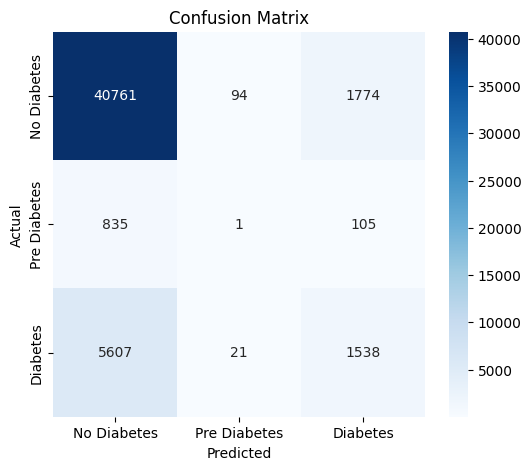

In [31]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Diabetes', 'Pre Diabetes','Diabetes'], yticklabels=['No Diabetes', 'Pre Diabetes','Diabetes'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [32]:
print('Confusion Matrix:')
print(cm)

Confusion Matrix:
[[40761    94  1774]
 [  835     1   105]
 [ 5607    21  1538]]


In [33]:
from sklearn.ensemble import RandomForestClassifier

# Assuming this is your trained model
model = RandomForestClassifier()
model.fit(X_train, y_train)  # Replace with your training data

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [34]:
import joblib

# Save the model after training (if not done already)
joblib.dump(model, 'random_forest_model.pkl')

# Load the model for prediction
model = joblib.load('random_forest_model.pkl')

In [35]:
joblib.dump(model, 'random_forest_model.pkl')

['random_forest_model.pkl']

In [37]:
import numpy as np
import pandas as pd
import joblib

# Load the trained Random Forest model
model = joblib.load('random_forest_model.pkl')  # Ensure this file exists in your working directory

# Example input values (replace with your actual values)
input_data = np.array([[1, 1, 1, 35, 1, 1, 1, 0, 0, 0, 0, 1, 1, 5, 8, 10, 1, 0, 60]])

# Define column names based on your dataset
columns = ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 
           'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 
           'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 
           'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age']

# Convert the input array into a DataFrame
input_df = pd.DataFrame(input_data, columns=columns)

# Predict the class
prediction = model.predict(input_df)

# Print the result
if prediction[0] == 0:
    print("Prediction: No Diabetes")
elif prediction[0] == 1:
    print("Prediction: Pre-Diabetes")
else:
    print("Prediction: Diabetes")

# Optional: Predict probabilities for each class
probabilities = model.predict_proba(input_df)
print("Class Probabilities:", probabilities)

Prediction: Diabetes
Class Probabilities: [[0.3  0.06 0.64]]


In [38]:
train_accuracy = classifier.score(X_train, y_train)
test_accuracy = classifier.score(X_test, y_test)

print(f'Training Accuracy: {train_accuracy:.2f}')
print(f'Test Accuracy: {test_accuracy:.2f}')

Training Accuracy: 0.97
Test Accuracy: 0.83


In [39]:
X_train.info()


<class 'pandas.core.frame.DataFrame'>
Index: 202944 entries, 104176 to 93028
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   HighBP                202944 non-null  int64
 1   HighChol              202944 non-null  int64
 2   CholCheck             202944 non-null  int64
 3   BMI                   202944 non-null  int64
 4   Smoker                202944 non-null  int64
 5   Stroke                202944 non-null  int64
 6   HeartDiseaseorAttack  202944 non-null  int64
 7   PhysActivity          202944 non-null  int64
 8   Fruits                202944 non-null  int64
 9   Veggies               202944 non-null  int64
 10  HvyAlcoholConsump     202944 non-null  int64
 11  AnyHealthcare         202944 non-null  int64
 12  NoDocbcCost           202944 non-null  int64
 13  GenHlth               202944 non-null  int64
 14  MentHlth              202944 non-null  int64
 15  PhysHlth              202944 non-nu

In [40]:
from sklearn.metrics import f1_score

# Calculate F1 score
f1 = f1_score(y_test, test_pred, average='weighted')

print('F1 Score is: ', f1)

F1 Score is:  0.8035748625375763


# Heatmap

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


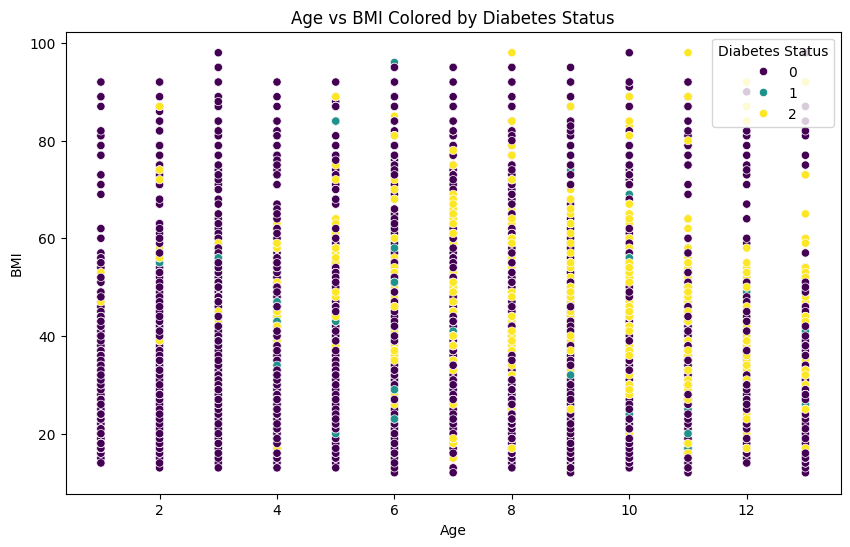

In [41]:
# Scatterplot of Age vs BMI colored by Diabetes Status
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='BMI', hue='Diabetes_012', data=dataframe, palette='viridis')
plt.title('Age vs BMI Colored by Diabetes Status')
plt.xlabel('Age')
plt.ylabel('BMI')
plt.legend(title='Diabetes Status')
plt.show()

In [42]:
res = pd.DataFrame({'actual value':y_test,'predicted value':test_pred})

In [43]:
res

,actual value,predicted value
238582,0,0
34895,0,0
630,0,0
160501,0,0
99143,0,0
...,...,...
218443,0,0
95316,0,0
130316,2,2
108964,2,0


# Performance Metrics

In [44]:
from sklearn.metrics import classification_report

# Generate the classification report
print("Classification Report:")
print(classification_report(y_test, test_pred, target_names=['No Diabetes', 'Pre Diabetes', 'Diabetes']))

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.86      0.96      0.91     42629
Pre Diabetes       0.01      0.00      0.00       941
    Diabetes       0.45      0.21      0.29      7166

    accuracy                           0.83     50736
   macro avg       0.44      0.39      0.40     50736
weighted avg       0.79      0.83      0.80     50736



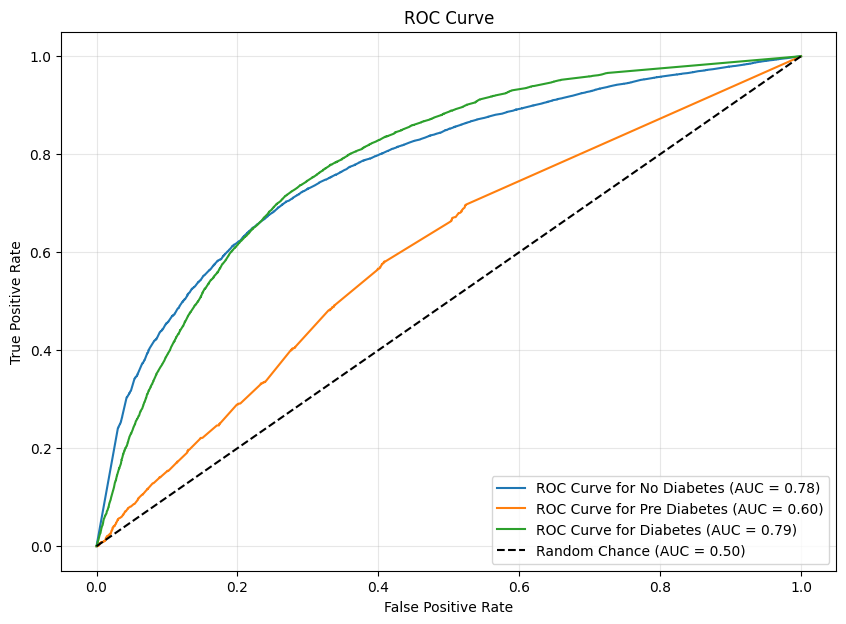

In [45]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Binarize the labels for multi-class ROC curve
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])
test_pred_prob = classifier.predict_proba(X_test)

# Plot the ROC curve for each class
plt.figure(figsize=(10, 7))
for i, label in enumerate(['No Diabetes', 'Pre Diabetes', 'Diabetes']):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], test_pred_prob[:, i])
    plt.plot(fpr, tpr, label=f"ROC Curve for {label} (AUC = {roc_auc_score(y_test_binarized[:, i], test_pred_prob[:, i]):.2f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Chance (AUC = 0.50)")
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


# Class Distribution Graph

/tmp/ipykernel_58/4048972898.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=dataframe['Diabetes_012'], palette="viridis")


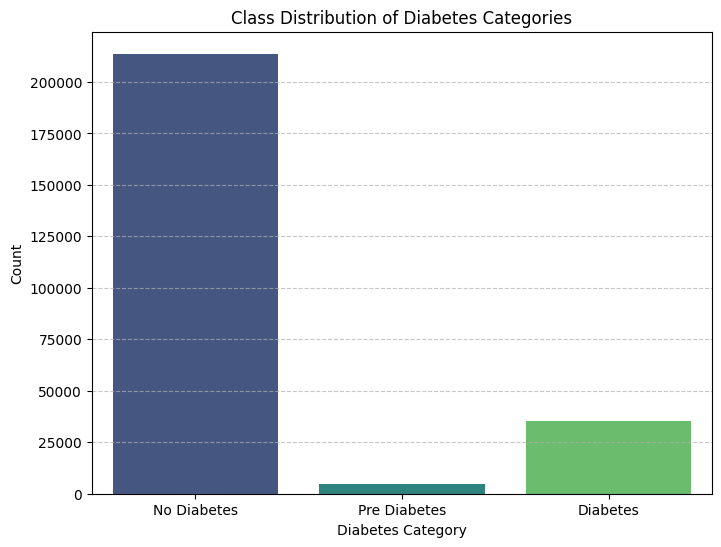

In [46]:
# Visualize the class distribution
plt.figure(figsize=(8, 6))
sns.countplot(x=dataframe['Diabetes_012'], palette="viridis")
plt.title('Class Distribution of Diabetes Categories')
plt.xlabel('Diabetes Category')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1, 2], labels=['No Diabetes', 'Pre Diabetes', 'Diabetes'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [47]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize and train KNN model
knn_classifier = KNeighborsClassifier(n_neighbors=5)  # You can adjust n_neighbors
knn_classifier.fit(X_train, y_train)

# Make predictions
knn_test_pred = knn_classifier.predict(X_test)

# Evaluate KNN model
knn_accuracy = accuracy_score(y_test, knn_test_pred)
print(f'KNN Accuracy score is {knn_accuracy * 100:.2f}')

KNN Accuracy score is 83.01


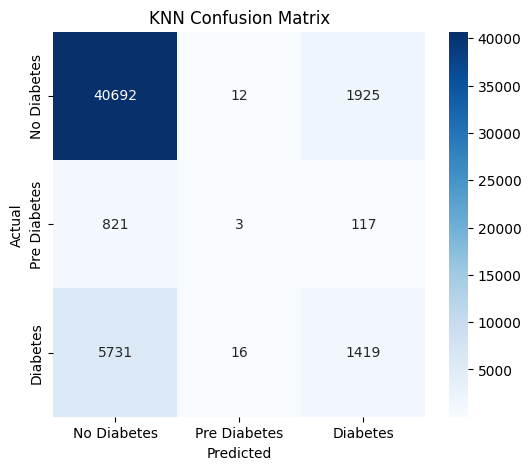

/tmp/ipykernel_58/380063138.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_test, palette='Set2')
/tmp/ipykernel_58/380063138.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=knn_test_pred, palette='Set2')


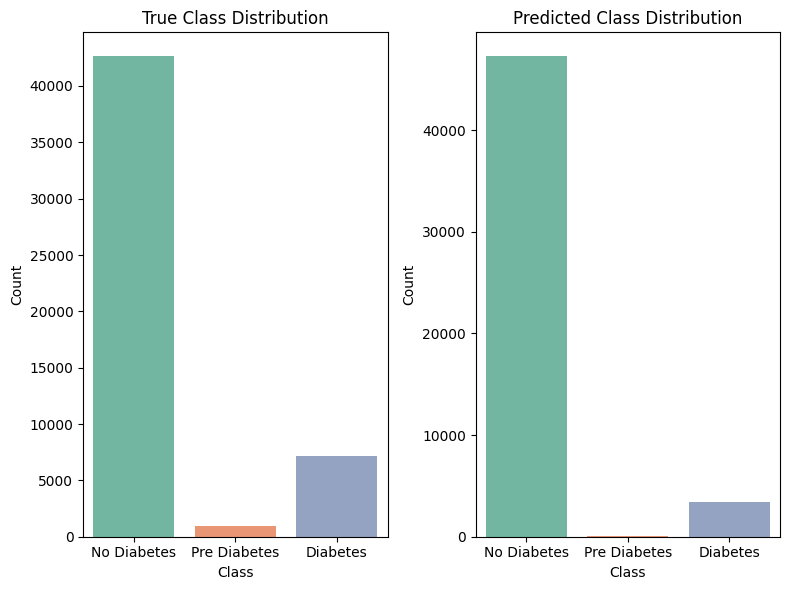

In [48]:
# Confusion matrix for KNN
knn_cm = confusion_matrix(y_test, knn_test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(knn_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Diabetes', 'Pre Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Pre Diabetes', 'Diabetes'])
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

plt.figure(figsize=(8, 6))
plt.subplot(1, 2, 1)
sns.countplot(x=y_test, palette='Set2')
plt.title('True Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks([0, 1, 2], ['No Diabetes', 'Pre Diabetes', 'Diabetes'])

plt.subplot(1, 2, 2)
sns.countplot(x=knn_test_pred, palette='Set2')
plt.title('Predicted Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks([0, 1, 2], ['No Diabetes', 'Pre Diabetes', 'Diabetes'])

plt.tight_layout()
plt.show()

In [49]:
knn_f1 = f1_score(y_test, knn_test_pred, average='weighted')
print('KNN F1 Score is: ', knn_f1)

# Classification report for KNN
print("KNN Classification Report:")
print(classification_report(y_test, knn_test_pred, target_names=['No Diabetes', 'Pre Diabetes', 'Diabetes']))

# Save the KNN model
import joblib
joblib.dump(knn_classifier, 'knn_model.pkl')
print("KNN Model saved as knn_model.pkl")

KNN F1 Score is:  0.7986830899796254
KNN Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.86      0.95      0.91     42629
Pre Diabetes       0.10      0.00      0.01       941
    Diabetes       0.41      0.20      0.27      7166

    accuracy                           0.83     50736
   macro avg       0.46      0.39      0.39     50736
weighted avg       0.78      0.83      0.80     50736

KNN Model saved as knn_model.pkl


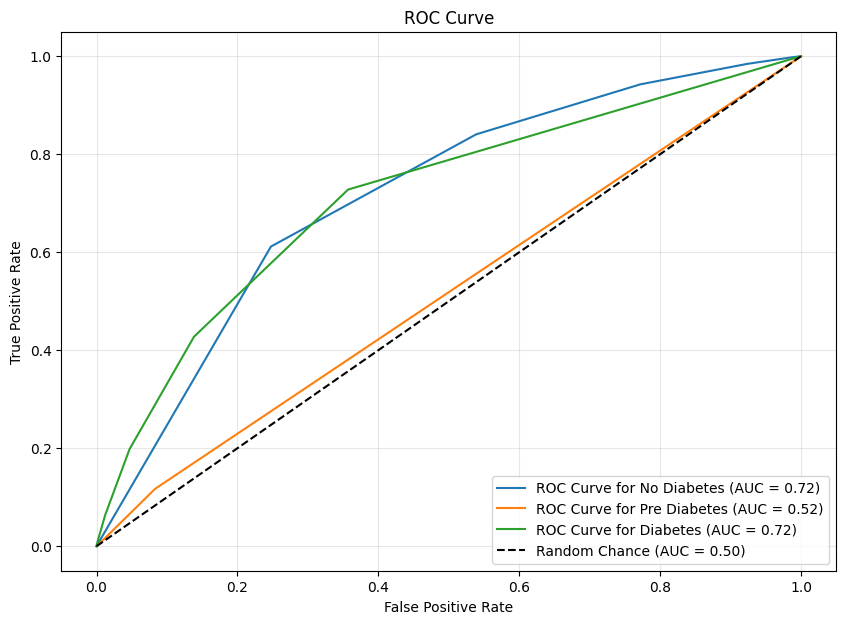

In [50]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Binarize the labels for multi-class ROC curve
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])
test_pred_prob = knn_classifier.predict_proba(X_test)

# Plot the ROC curve for each class
plt.figure(figsize=(10, 7))
for i, label in enumerate(['No Diabetes', 'Pre Diabetes', 'Diabetes']):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], test_pred_prob[:, i])
    plt.plot(fpr, tpr, label=f"ROC Curve for {label} (AUC = {roc_auc_score(y_test_binarized[:, i], test_pred_prob[:, i]):.2f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Chance (AUC = 0.50)")
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()